In [6]:
import pandas as pd

data = pd.read_csv(r"C:\Users\HP\Desktop\Student-Study-Pattern-Analyzer\data\student_data.csv\Untitled form.csv")
print(data.head())

                        Timestamp    Study Hours per Day     \
0  2026/03/29 2:05:23 AM GMT+5:30                         2   
1  2026/03/29 2:05:50 AM GMT+5:30                         4   
2  2026/03/29 2:05:51 AM GMT+5:30                         3   
3  2026/03/29 2:06:10 AM GMT+5:30                         2   
4  2026/03/29 2:06:12 AM GMT+5:30                         8   

   Sleep Hours per Day    Daily Mobile Usage (in hours)  \
0                      6                              4   
1                      7                              5   
2                      5                              3   
3                      9                              1   
4                      9                              5   

   Attendance Percentage    Internal Marks (out of 100)    
0                       82                             78  
1                       89                             78  
2                       75                             66  
3                       90

In [7]:
# Rename columns
data.columns = [
    "Timestamp",
    "StudyHours",
    "SleepHours",
    "MobileUsage",
    "Attendance",
    "Marks"
]

# Drop timestamp column
data = data.drop("Timestamp", axis=1)

# Convert all values to numbers
data = data.astype(float)

print(data.head())

   StudyHours  SleepHours  MobileUsage  Attendance  Marks
0         2.0         6.0          4.0        82.0   78.0
1         4.0         7.0          5.0        89.0   78.0
2         3.0         5.0          3.0        75.0   66.0
3         2.0         9.0          1.0        90.0   79.0
4         8.0         9.0          5.0        92.0   89.0


In [2]:
!pip install seaborn matplotlib

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
import sys
!{sys.executable} -m pip install seaborn matplotlib

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

data = pd.read_csv(r"C:\Users\HP\Desktop\Student-Study-Pattern-Analyzer\data\student_data.csv\Untitled form.csv")
print(data.head())

                        Timestamp    Study Hours per Day     \
0  2026/03/29 2:05:23 AM GMT+5:30                         2   
1  2026/03/29 2:05:50 AM GMT+5:30                         4   
2  2026/03/29 2:05:51 AM GMT+5:30                         3   
3  2026/03/29 2:06:10 AM GMT+5:30                         2   
4  2026/03/29 2:06:12 AM GMT+5:30                         8   

   Sleep Hours per Day    Daily Mobile Usage (in hours)  \
0                      6                              4   
1                      7                              5   
2                      5                              3   
3                      9                              1   
4                      9                              5   

   Attendance Percentage    Internal Marks (out of 100)    
0                       82                             78  
1                       89                             78  
2                       75                             66  
3                       90

In [3]:
data.columns = [
    "Timestamp",
    "StudyHours",
    "SleepHours",
    "MobileUsage",
    "Attendance",
    "Marks"
]

data = data.drop("Timestamp", axis=1)
data = data.astype(float)

print(data.head())

   StudyHours  SleepHours  MobileUsage  Attendance  Marks
0         2.0         6.0          4.0        82.0   78.0
1         4.0         7.0          5.0        89.0   78.0
2         3.0         5.0          3.0        75.0   66.0
3         2.0         9.0          1.0        90.0   79.0
4         8.0         9.0          5.0        92.0   89.0


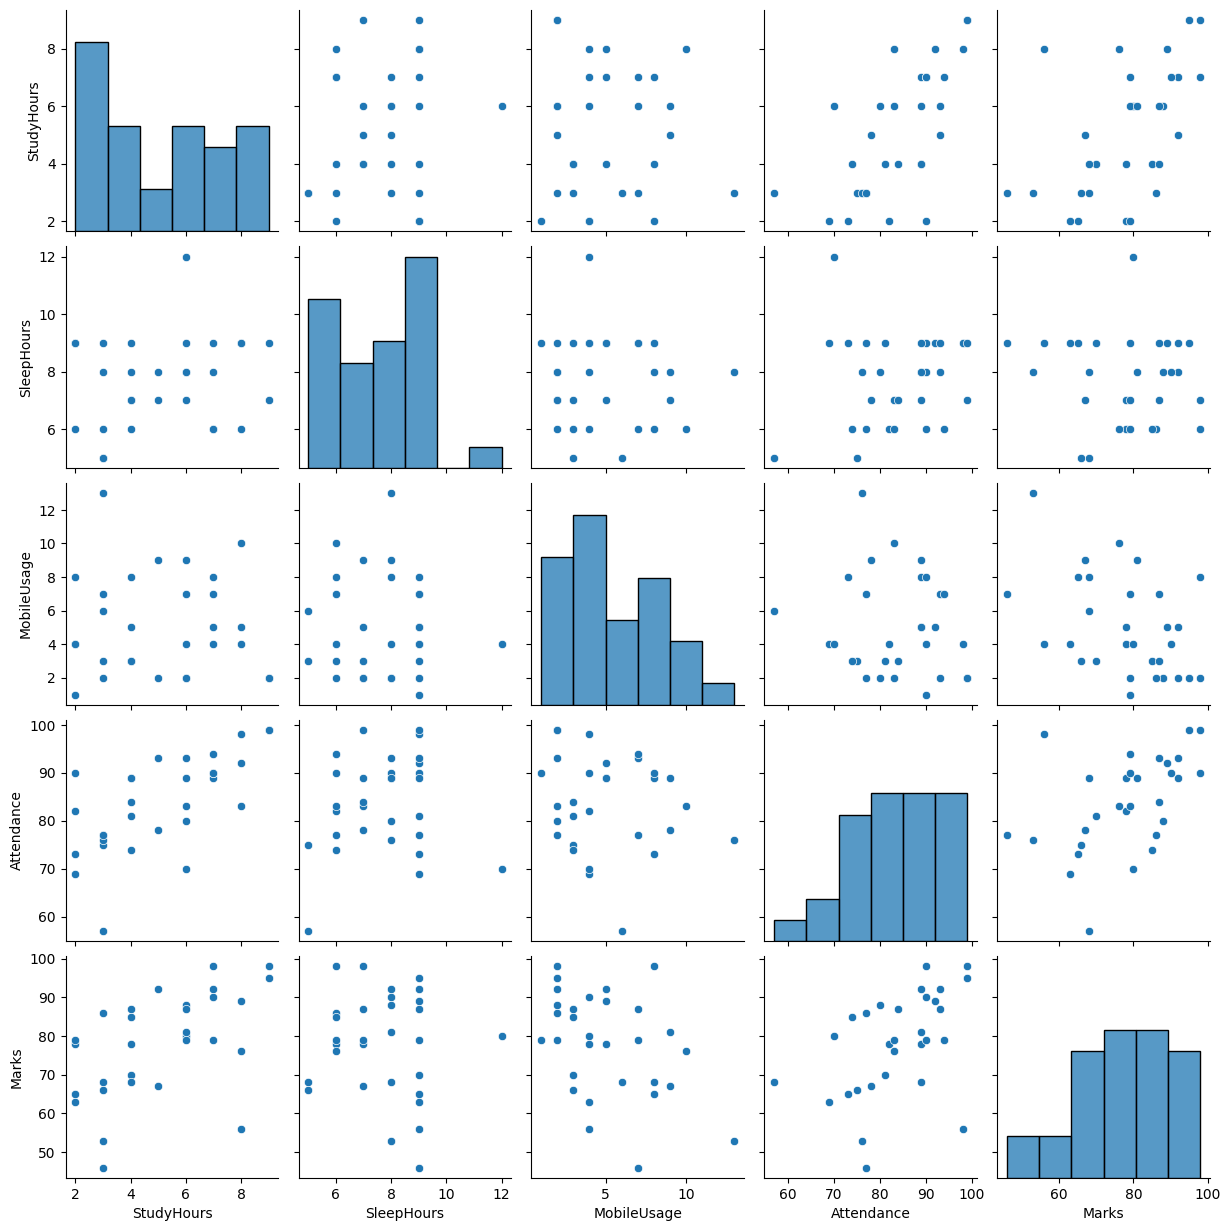

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(data)
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features (input)
X = data[['StudyHours', 'SleepHours', 'MobileUsage', 'Attendance']]

# Target (output)
y = data['Marks']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

print("Predictions:", predictions)

Predictions: [54.64693933 82.62761368 88.39920043 63.14465218 74.87461232 84.1210327 ]


In [6]:
from sklearn.tree import DecisionTreeRegressor

model2 = DecisionTreeRegressor()
model2.fit(X_train, y_train)

pred2 = model2.predict(X_test)

print("Decision Tree Predictions:", pred2)

Decision Tree Predictions: [67. 78. 88. 63. 79. 85.]


In [7]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, predictions)
print("Mean Squared Error:", mse)

Mean Squared Error: 124.40192692063054


In [8]:
import pandas as pd

importance = model.coef_

feature_importance = pd.DataFrame({
    'Feature': ['StudyHours', 'SleepHours', 'MobileUsage', 'Attendance'],
    'Importance': importance
})

print(feature_importance)

       Feature  Importance
0   StudyHours    2.072079
1   SleepHours   -3.353063
2  MobileUsage   -1.976386
3   Attendance    0.348959
